In [401]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.metrics import r2_score

import joblib

url = "https://raw.githubusercontent.com/parmveer99solanki99-pixel/Data-Science/refs/heads/main/ai_chip_market.csv"
df = pd.read_csv(url)

print("\nShape:", df.shape)
print("\nInformations:", df.info())

print("\nDescribetion:", df.describe())


Shape: (120, 11)
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       120 non-null    int64  
 1   chip_name                  120 non-null    str    
 2   vendor                     120 non-null    str    
 3   launch_date                120 non-null    str    
 4   memory_gb                  120 non-null    int64  
 5   fp16_tflops                120 non-null    int64  
 6   tdp_watts                  120 non-null    int64  
 7   estimated_shipments_units  120 non-null    int64  
 8   estimated_asp_usd          120 non-null    int64  
 9   estimated_revenue_usd_m    120 non-null    float64
 10  description                120 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 10.4 KB

Informations: None

Describetion:               year    memory_gb  fp16_tflops     tdp_watts  \
coun

In [402]:
# Handle Missing Values

print("\nMissing Values:")
print(df.isnull().sum())
print(df.dropna(inplace = True))

# Remove Duplicates Values
print("\nDuplicates:")
print(df.duplicated().sum())
print(df.drop_duplicates())


Missing Values:
year                         0
chip_name                    0
vendor                       0
launch_date                  0
memory_gb                    0
fp16_tflops                  0
tdp_watts                    0
estimated_shipments_units    0
estimated_asp_usd            0
estimated_revenue_usd_m      0
description                  0
dtype: int64
None

Duplicates:
0
     year       chip_name  vendor launch_date  memory_gb  fp16_tflops  \
0    2020     NVIDIA V100  NVIDIA  2017-05-10         32          100   
1    2021     NVIDIA V100  NVIDIA  2017-05-10         32          100   
2    2022     NVIDIA V100  NVIDIA  2017-05-10         32          100   
3    2023     NVIDIA V100  NVIDIA  2017-05-10         32          100   
4    2024     NVIDIA V100  NVIDIA  2017-05-10         32          100   
..    ...             ...     ...         ...        ...          ...   
115  2024  Apple M4 (NPU)   Apple  2024-05-07         16           38   
116  2025  Apple M4 (NPU)

In [403]:
print("\nData Types:")
print(df.dtypes)

# Handle Missing Values
print("\nMissing Value:")
print(df.isnull().sum())
print(df.dropna(inplace = True))

# Remove Duplicates
print("Duplicates Values:")
print(df.duplicated().sum())
print(df.drop_duplicates(inplace = True))


Data Types:
year                           int64
chip_name                        str
vendor                           str
launch_date                      str
memory_gb                      int64
fp16_tflops                    int64
tdp_watts                      int64
estimated_shipments_units      int64
estimated_asp_usd              int64
estimated_revenue_usd_m      float64
description                      str
dtype: object

Missing Value:
year                         0
chip_name                    0
vendor                       0
launch_date                  0
memory_gb                    0
fp16_tflops                  0
tdp_watts                    0
estimated_shipments_units    0
estimated_asp_usd            0
estimated_revenue_usd_m      0
description                  0
dtype: int64
None
Duplicates Values:
0
None


In [404]:
# Estimated_shipments_units
print("\nTotal Units:")
print(df['estimated_shipments_units'].sum())

vendor = (df.groupby("vendor")["estimated_shipments_units"].sum())
print("\nVendor-wise Chip Units:")
print(vendor)

estimated_revenue_usd = (df.groupby("vendor")['estimated_revenue_usd_m'].sum())
print("\nTotal Revenue:")
print(estimated_revenue_usd)


Total Units:
14107775

Vendor-wise Chip Units:
vendor
AMD            1044482
AWS             531586
Apple             2888
Cambricon         2619
Cerebras          2090
Google         2735594
Groq             59638
Huawei          754463
NVIDIA         8964751
SambaNova         7839
Tenstorrent       1825
Name: estimated_shipments_units, dtype: int64

Total Revenue:
vendor
AMD             19166.6
AWS              7973.8
Apple              43.2
Cambricon          39.3
Cerebras         5225.0
Google          23365.8
Groq              894.6
Huawei          11707.5
NVIDIA         254064.5
SambaNova         117.7
Tenstorrent        27.3
Name: estimated_revenue_usd_m, dtype: float64


In [405]:
print("\nTotal Units:")
print(df['estimated_shipments_units'].sum())

vendor = (df.groupby("vendor")["estimated_shipments_units"].sum())
print("\nVendor-wise Chip Units:")
print(vendor)

estimated_revenue_usd = (df.groupby("vendor")['estimated_revenue_usd_m'].sum())
print("\nTotal Revenue:")
print(estimated_revenue_usd)


Total Units:
14107775

Vendor-wise Chip Units:
vendor
AMD            1044482
AWS             531586
Apple             2888
Cambricon         2619
Cerebras          2090
Google         2735594
Groq             59638
Huawei          754463
NVIDIA         8964751
SambaNova         7839
Tenstorrent       1825
Name: estimated_shipments_units, dtype: int64

Total Revenue:
vendor
AMD             19166.6
AWS              7973.8
Apple              43.2
Cambricon          39.3
Cerebras         5225.0
Google          23365.8
Groq              894.6
Huawei          11707.5
NVIDIA         254064.5
SambaNova         117.7
Tenstorrent        27.3
Name: estimated_revenue_usd_m, dtype: float64


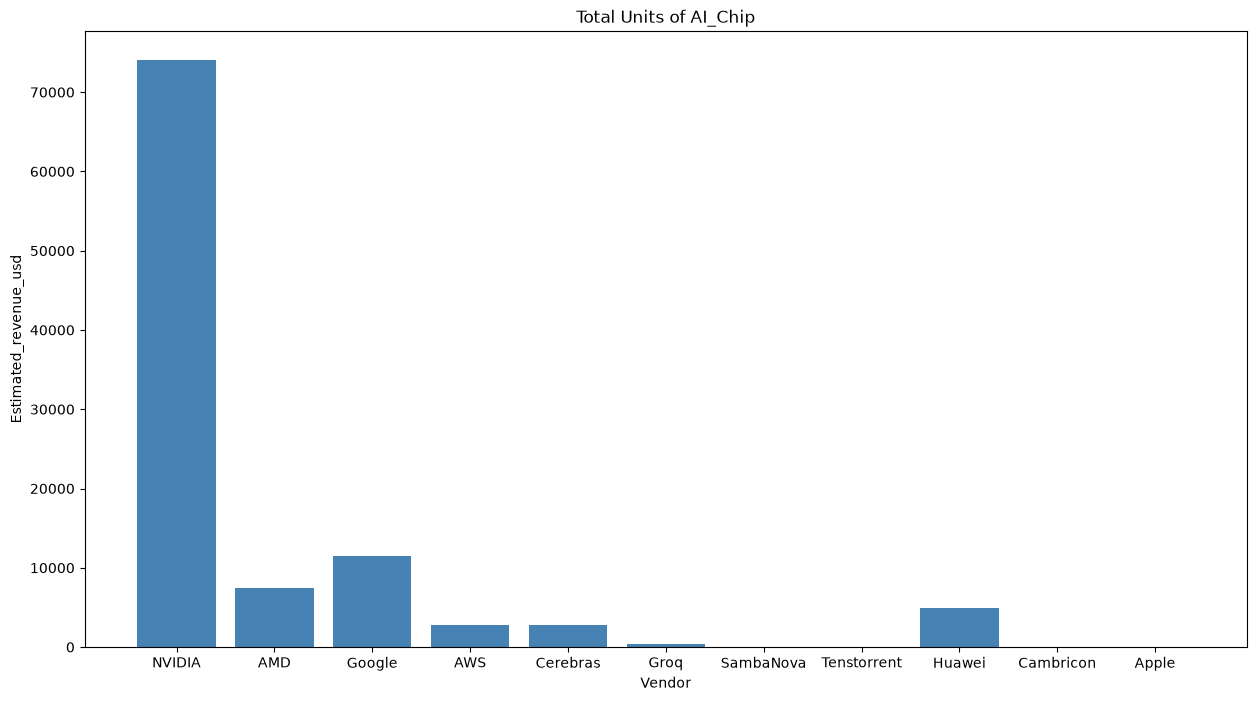

In [406]:
# Vendor Vs Estimated_revenue_usd

plt.figure(figsize = (15,8))
plt.bar(df['vendor'], df['estimated_revenue_usd_m'], color = 'steelblue')

plt.xlabel("Vendor")
plt.ylabel("Estimated_revenue_usd")
plt.title("Total Units of AI_Chip")
plt.show()


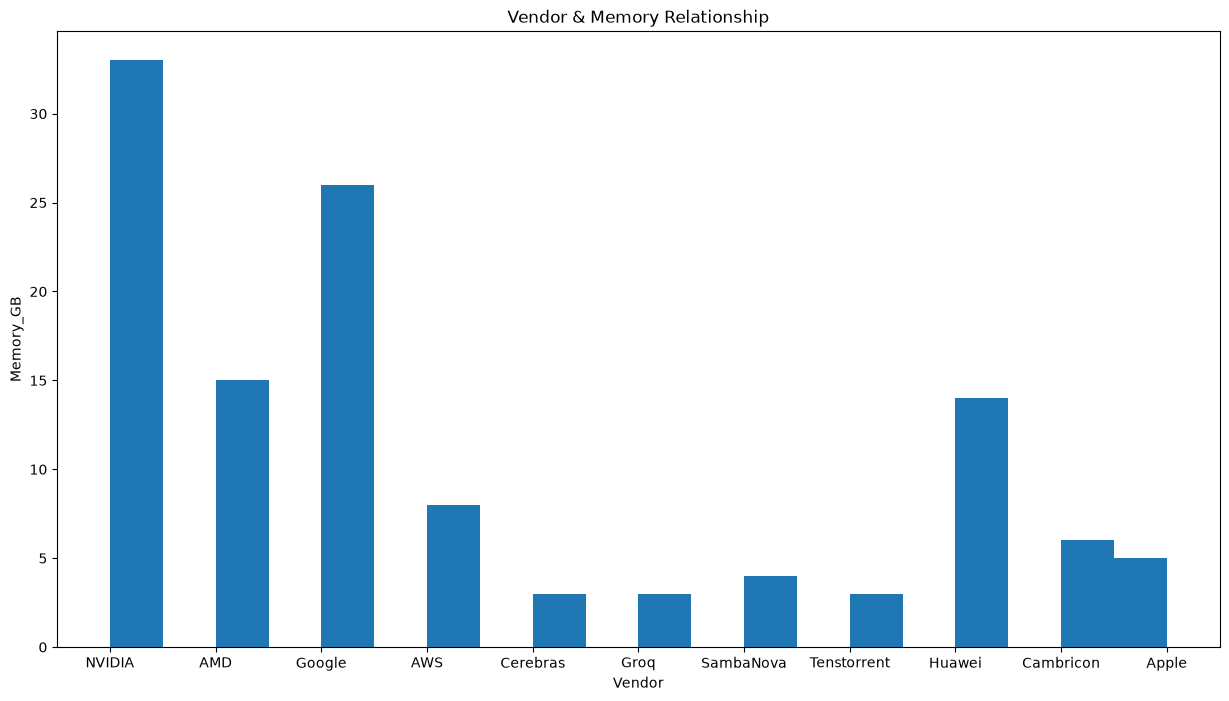

In [407]:
# Vendor Vs Memory_gb

plt.figure(figsize = (15, 8))
plt.hist(df['vendor'], bins = 20)

plt.xlabel("Vendor")
plt.ylabel("Memory_GB")
plt.title("Vendor & Memory Relationship")
plt.show()

In [408]:
# Input
features = ["year","chip_name", "vendor", "memory_gb", "fp16_tflops", "tdp_watts"]

X = df[features]

# Output
y = df[['estimated_shipments_units', 'estimated_revenue_usd_m']]

In [409]:
# Feature Enginnering


encoder = LabelEncoder()

for col in ["chip_name", "vendor"]:
    X[col] = encoder.fit_transform(x[col].astype(str))

In [410]:
# Model Training

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("\nMSE:", mean_absolute_error(y_test, prediction))
print("\nR2 Score :", r2_score(y_test, prediction))
print("\nMAE:", mean_absolute_error(y_test, prediction))



MSE: 61142.122312499996

R2 Score : -2.366507626799865

MAE: 61142.122312499996


In [411]:

sample = pd.DataFrame({"year": [2026],
    "chip_name": [10],
    "vendor": [2],
    "memory_gb": [32],
    "fp16_tflops": [120],
    "tdp_watts": [350],
})

prediction = model.predict(sample)

print("\nprediction:", prediction)


prediction: [[30483.43    457.259]]


In [412]:
# 

joblib.dump(model, "AI_Semiconductor_model.joblib")



['AI_Semiconductor_model.joblib']